In [1]:
!pip install mplcyberpunk --quiet
!pip install cmasher --quiet
!pip install polars --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 MB 40.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-polars-cu12 25.6.0 requires polars<1.29,>=1.25, but you have polars 1.35.2 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-cu12==25.6.*, but you have pylibcudf-cu12 25.2.2 which is incompatible.


### City Lifestyle EDA and Clustering

#### Imports

In [2]:
import os
import kagglehub
import warnings
import mplcyberpunk
import cmasher
import numpy as np
import polars as pl
import polars.selectors as cs

import matplotlib.pyplot as plt
import matplotlib.patches as pt

from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, SpectralClustering, OPTICS
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

warnings.filterwarnings('ignore')
plt.style.use('cyberpunk')

#### Loading and visualizing data statistics

In [3]:
df = pl.read_csv('/kaggle/input/city-lifestyle-segmentation-dataset/city_lifestyle_dataset.csv').rename({'country' : 'region'})
df = df.rename({col.name : col.name.replace('_', ' ').capitalize() for col in df})

In [4]:
df.head()

City name,Region,Population density,Avg income,Internet penetration,Avg rent,Air quality index,Public transport score,Happiness score,Green space ratio
str,str,i64,i64,f64,i64,i64,f64,f64,f64
"""Old Vista""","""Europe""",2775,3850,86.4,1310,43,52.0,8.5,23.8
"""Beachport""","""Europe""",3861,3700,78.1,1330,42,62.8,8.1,33.1
"""Valleyborough""","""Europe""",2562,4310,80.1,1330,39,73.2,8.5,40.2
"""City""","""Europe""",3192,3970,81.2,1480,60,49.2,8.5,43.6
"""Falls""","""Europe""",3496,4320,100.0,1510,64,93.7,8.5,42.5


In [5]:
df.tail()

City name,Region,Population density,Avg income,Internet penetration,Avg rent,Air quality index,Public transport score,Happiness score,Green space ratio
str,str,i64,i64,f64,i64,i64,f64,f64,f64
"""Old Harbor""","""Oceania""",1004,4620,100.0,1500,40,64.2,8.5,50.2
"""Ridgehaven""","""Oceania""",1652,4500,100.0,1650,44,49.3,8.5,37.4
"""North Field""","""Oceania""",836,3910,98.7,1340,40,55.7,8.5,38.6
"""Bridgeford""","""Oceania""",758,3490,91.2,1390,36,54.1,8.5,44.6
"""Townshire""","""Oceania""",1235,4330,86.4,1150,41,75.3,8.5,39.9


In [6]:
df.describe()

statistic,City name,Region,Population density,Avg income,Internet penetration,Avg rent,Air quality index,Public transport score,Happiness score,Green space ratio
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""300""","""300""",300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,3944.843333,2827.2,74.305333,1002.766667,71.246667,55.717333,6.644,33.993333
"""std""",null,null,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
"""min""","""Bay""","""Africa""",100.0,480.0,34.0,170.0,22.0,15.0,2.5,2.0
"""25%""",null,null,1845.0,1910.0,64.5,640.0,54.0,46.1,5.3,28.3
"""50%""",null,null,3088.0,2820.0,75.0,990.0,68.0,54.7,6.9,34.8
"""75%""",null,null,4819.0,3750.0,87.2,1330.0,86.0,64.2,8.5,40.4
"""max""","""Woodville""","""South America""",14427.0,5720.0,100.0,2430.0,146.0,95.0,8.5,58.0


In [7]:
df.null_count()

City name,Region,Population density,Avg income,Internet penetration,Avg rent,Air quality index,Public transport score,Happiness score,Green space ratio
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0


In [8]:
numeric_cols = df.select(cs.numeric())

#### Plotting

In [9]:
colors = ['#00FFFF', '#24DBFF', '#49B6FF', '#6D92FF', '#926DFF', '#B649FF', '#DB24FF', '#FF00FF']

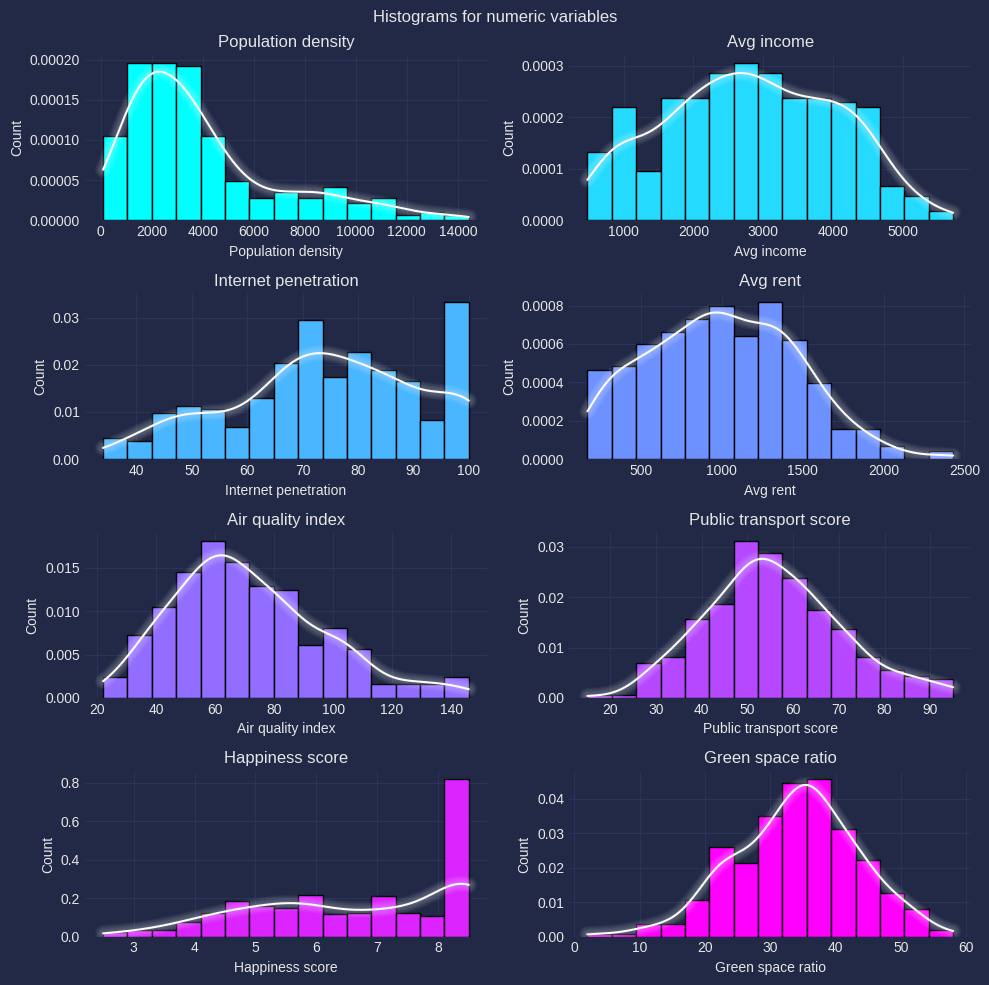

In [10]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(10,10))
fig.suptitle('Histograms for numeric variables')

for idx, col in enumerate(numeric_cols):
    axes = ax[idx // 2, idx % 2]
    kde = gaussian_kde(col)
    x_kde = np.linspace(col.min(), col.max(), len(col))
    axes.set_title(col.name)
    axes.set_xlabel(col.name)
    axes.set_ylabel('Count')
    axes.hist(col, bins=15, edgecolor='black', density=True, color=colors[idx])
    axes.plot(x_kde, kde(x_kde), color='white')
    mplcyberpunk.make_lines_glow(ax=axes)
    plt.tight_layout()

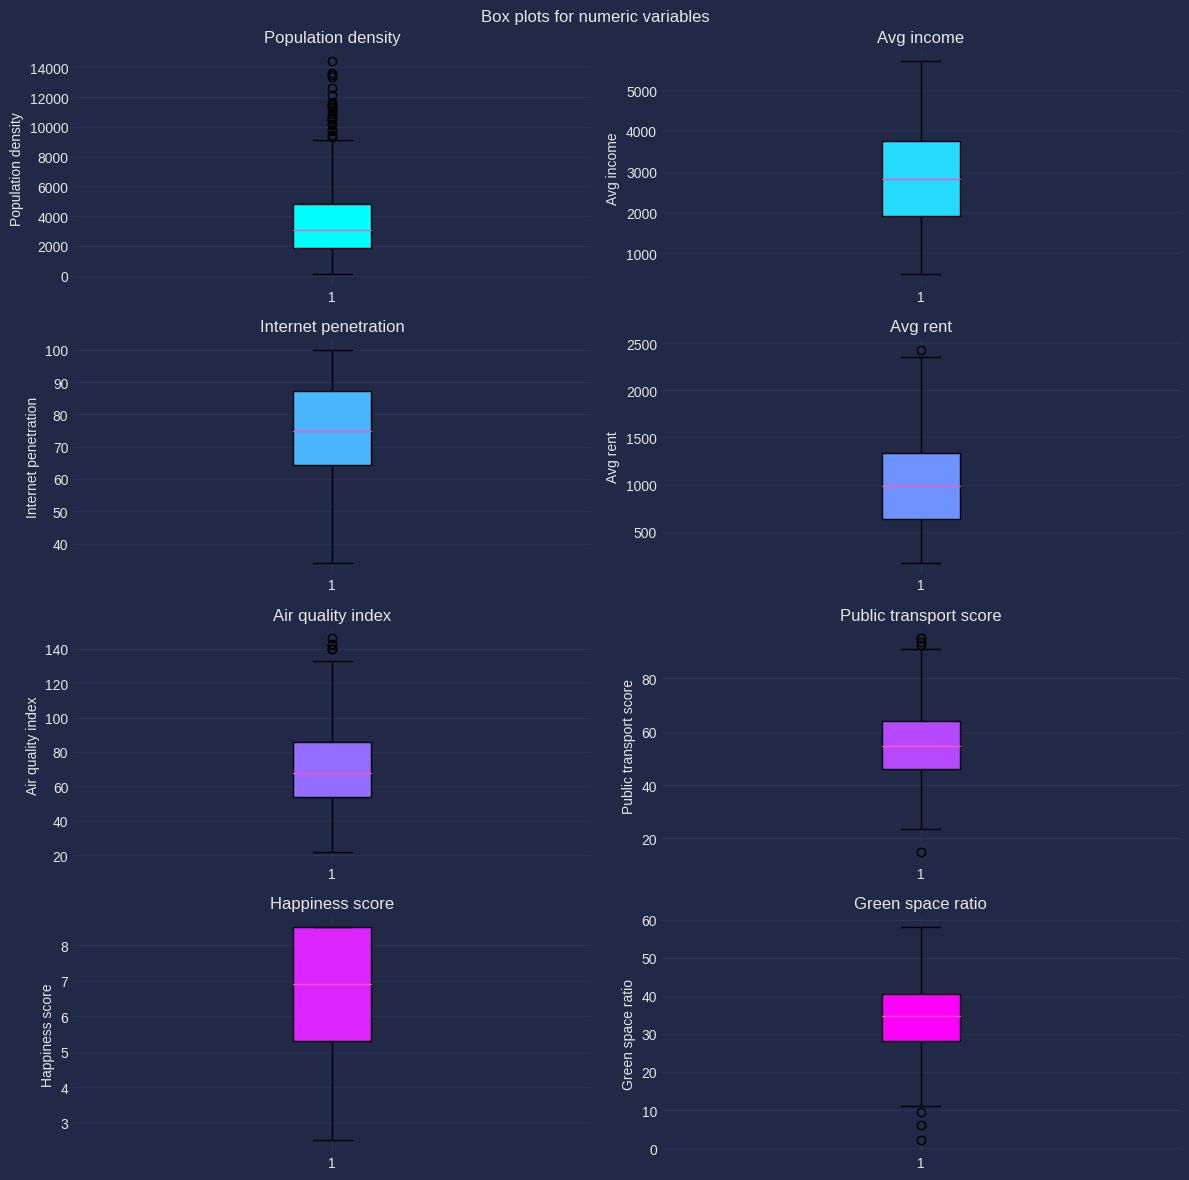

In [11]:
fig, ax = plt.subplots(nrows=4, ncols=2,  figsize=(12,12))
fig.suptitle('Box plots for numeric variables')

for idx, col in enumerate(numeric_cols):
    axes = ax[idx // 2, idx % 2]
    axes.set_title(col.name)
    axes.set_ylabel(col.name)
    bplot = axes.boxplot(col, patch_artist=True)
    bplot['boxes'][0].set_facecolor(colors[idx])
    plt.tight_layout()

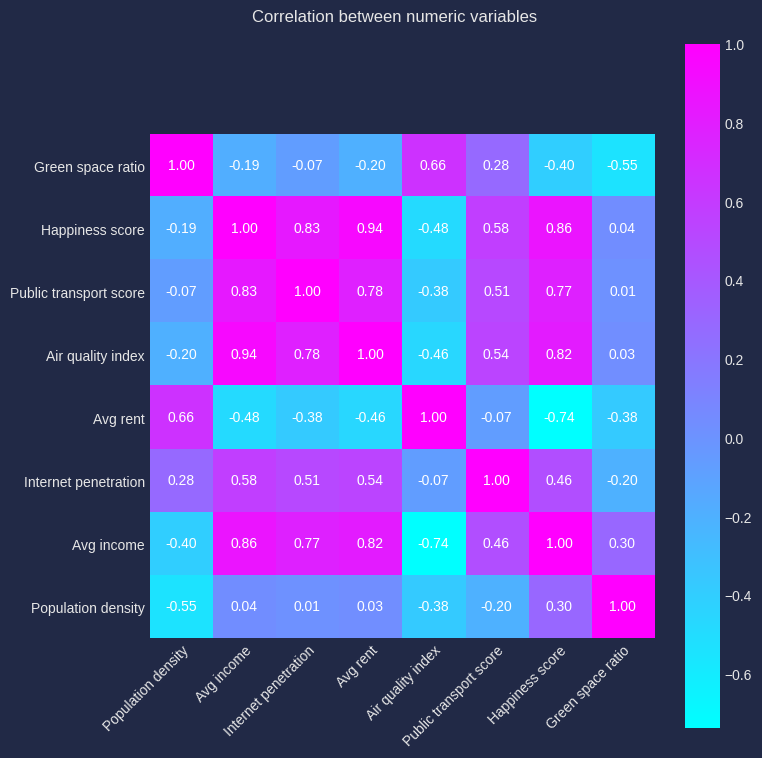

In [12]:
corr = numeric_cols.corr()
xticks = corr.columns
yticks = [xticks[i] for i in range(len(xticks)-1, -1, -1)]

fig, ax = plt.subplots(figsize=(8,8))
fig.suptitle('Correlation between numeric variables')
im = ax.imshow(corr, cmap="cool")
cbar = ax.figure.colorbar(im, ax=ax)
ax.grid(visible=False)
ax.set_xticks(range(len(xticks)), labels=xticks, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(yticks)), labels=yticks)

for i in range(len(xticks)):
    for j in range(len(yticks)):
        text = ax.text(j, i, "{:.2f}".format(corr[i, j]), ha="center", va="center", color="w")

fig.tight_layout()

#### Elbow calculation

In [13]:
elbow_scaler = StandardScaler()
elbow_reducer = PCA(n_components=8)

elbow_X_scaled = elbow_scaler.fit_transform(numeric_cols)
elbow_X_pca = elbow_reducer.fit_transform(elbow_X_scaled)

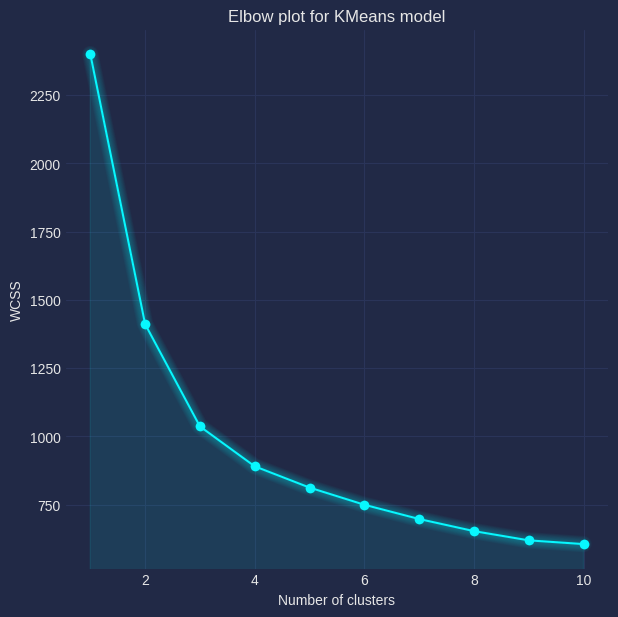

In [14]:
WCSS = []

for i in range(1, 11):
    current_kmeans = KMeans(n_clusters=i, init='k-means++')
    current_kmeans.fit(elbow_X_pca)
    WCSS.append(current_kmeans.inertia_)

fig, ax = plt.subplots(figsize=(7, 7))
plt.title('Elbow plot for KMeans model')
plt.plot(list(range(1, 11)), WCSS, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
mplcyberpunk.make_lines_glow(ax=ax)
mplcyberpunk.add_underglow(ax=ax)

#### Scaling and model fitting

In [15]:
scaler = StandardScaler()
reducer = PCA(n_components=2)

X_scaled = scaler.fit_transform(numeric_cols)
X_pca = reducer.fit_transform(X_scaled)

In [16]:
pca_df = {"PCA_" + str(i) : X_pca[:, i] for i in range(X_pca.shape[-1])}
pca_df = pl.DataFrame(pca_df)
pca_df.head()

PCA_0,PCA_1
f64,f64
-1.743192,0.071251
-1.641493,-0.014981
-2.411046,-0.320204
-1.74815,-0.758528
-3.078707,0.971714


In [17]:
models = {
    'KMeans' : KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init='auto'),
    'AgglomerativeClustering' : AgglomerativeClustering(n_clusters=4, linkage='ward', metric='euclidean'),
    'SpectralClustering' : SpectralClustering(n_clusters=4, affinity='rbf'),
    'DBSCAN' : DBSCAN(),
    'OPTICS' : OPTICS(min_samples=10),
    'MeanShift' : MeanShift(),
}

labels = {}

for name, model in models.items():
    current_label = model.fit_predict(X_pca)
    labels[name] = current_label
    pca_df = pca_df.with_columns(
        pl.Series(name, current_label)
    )

#### Plotting results

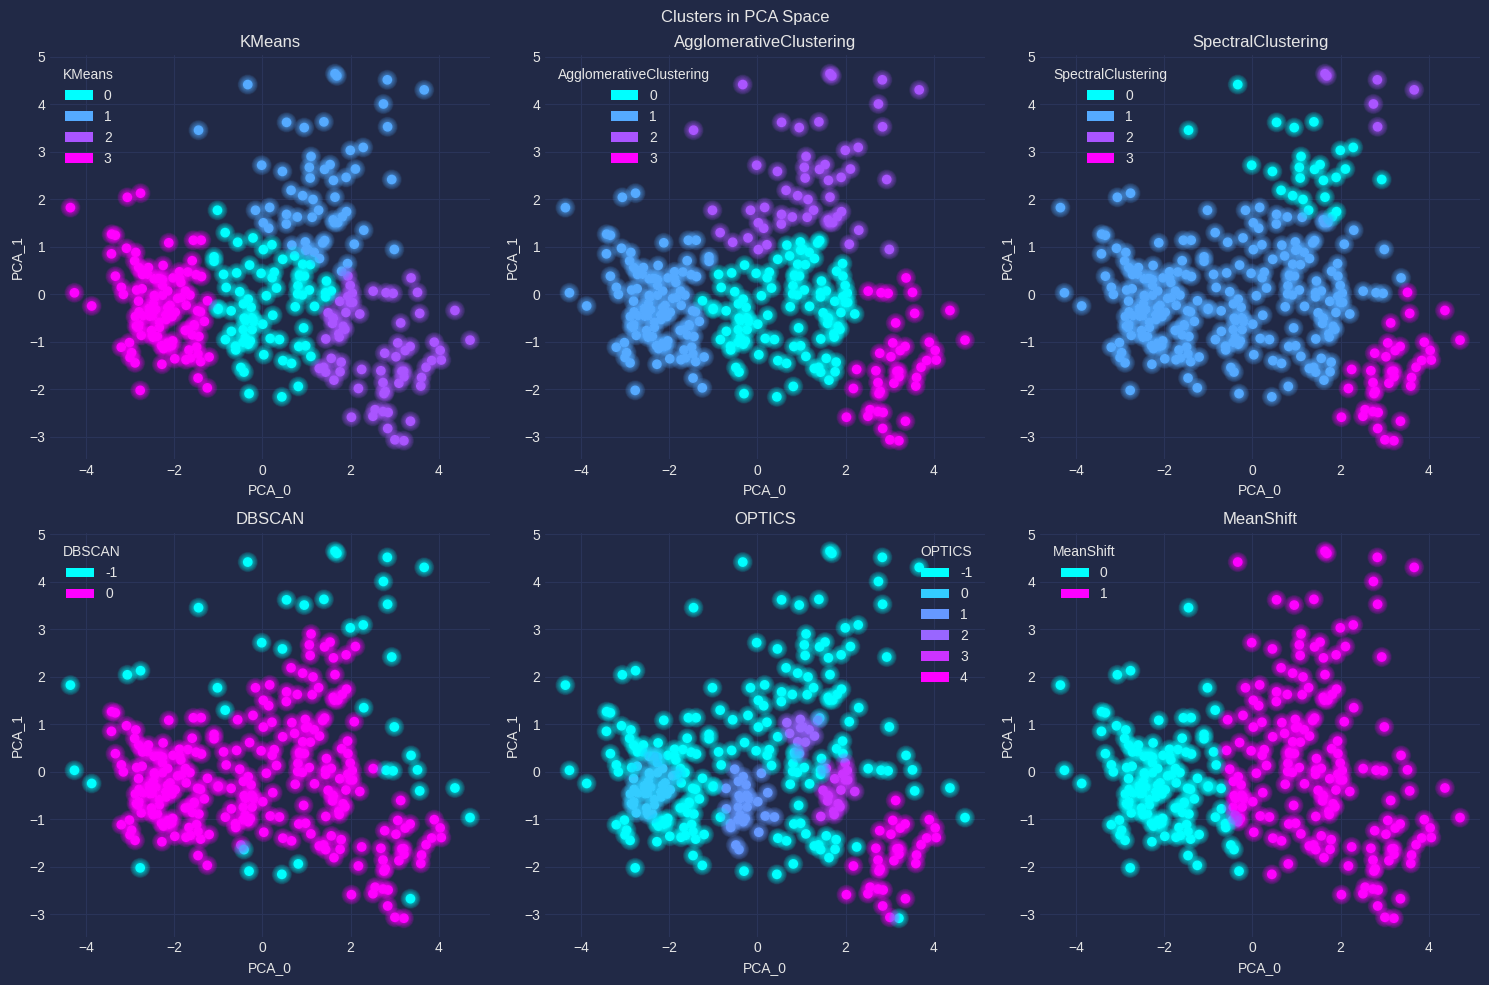

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle('Clusters in PCA Space')

def plot_scatter(axes, name, data):
    current_axes = axes
    current_axes.set_title(name)
    current_axes.set_xlabel('PCA_0')
    current_axes.set_ylabel('PCA_1')

    scatter = current_axes.scatter(data['PCA_0'], data['PCA_1'], c=data[name])
    colors = cmasher.take_cmap_colors(scatter.get_cmap(), N=len(data[name].unique()), return_fmt='rgba')
    labels = list(zip(data[name].unique().sort(descending=False).to_list(), range(len(colors))))
    handles = []
    for i in labels:
        handles.append(pt.Patch(facecolor=colors[i[1]], label=i[0]))
    current_axes.legend(handles=handles, title=name, loc='best')

for idx, name in enumerate(models.keys()):
    axes = ax[idx // 3, idx % 3]
    plot_scatter(axes=axes, name=name, data=pca_df)
    plt.sca(axes)
    mplcyberpunk.make_scatter_glow(ax=axes, alpha=0.8)

fig.tight_layout()

In [19]:
metrics = {
    'Calinski Harabasz Score': {},
    'Davies Bouldin Score': {},
    'Silhouette Score': {}
}

for name, label in labels.items():
    metrics['Calinski Harabasz Score'][name] = calinski_harabasz_score(X_pca, label)
    metrics['Davies Bouldin Score'][name] = davies_bouldin_score(X_pca, label)
    metrics['Silhouette Score'][name] = silhouette_score(X_pca, label)

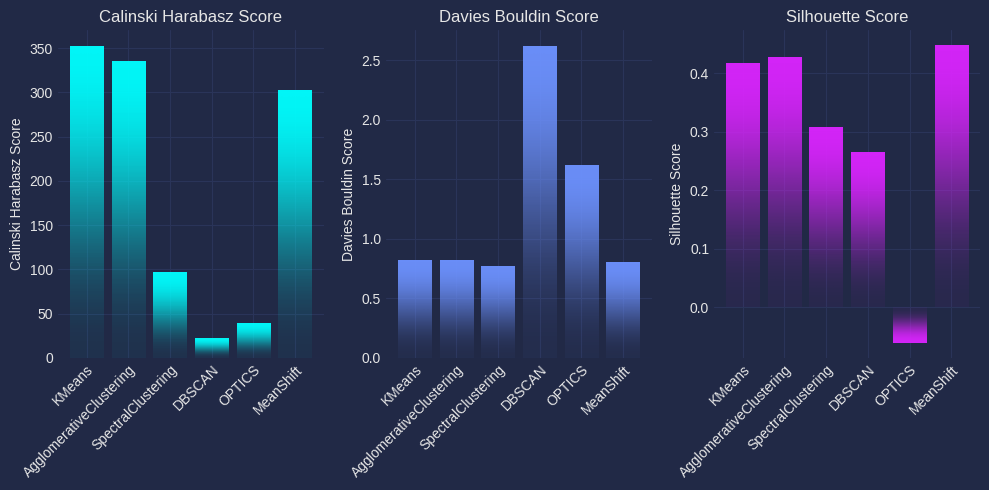

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5))

def plot_metric(axes, metrics, name, color):
    current_axes = axes
    current_axes.set_title(name)
    current_axes.set_xticks(range(len(metrics)), labels=metrics, rotation=45, ha="right", rotation_mode="anchor")
    current_axes.set_ylabel(name)
    current_bars = current_axes.bar(metrics.keys(), metrics.values(), color=color)
    plt.sca(current_axes)
    mplcyberpunk.add_bar_gradient(bars=current_bars, ax=current_axes)

for idx, metric in enumerate(metrics):
    axes = ax[idx]
    plot_metric(axes=ax[idx], metrics=metrics[metric], name=metric, color=colors[idx*3])

fig.tight_layout()